In [1]:
import io
import sys
from contextlib import redirect_stdout
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import contextily as cx
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# Clusters

Se corre algoritmo K-means para encontrar las regiones del país y poder hacer las respectivas divisiones para estudio

In [2]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn import linear_model
from sklearn import model_selection as ms
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

In [3]:
# Reading all sat condulted data

r = pd.read_csv(r'colombia_result_corrected.csv', usecols=(1,2,4,5),delimiter=',') # se carga el archivo .csv
r

,longitude,latitude,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,date
0,-71.495,11.925,1862.269873,2019-02-08 12:02:12
1,-71.745,11.915,1840.372803,2019-02-08 12:02:12
2,-71.755,11.915,1840.372803,2019-02-08 12:02:12
3,-71.765,11.915,1840.372803,2019-02-08 12:02:12
4,-71.775,11.915,1840.372803,2019-02-08 12:02:12
...,...,...,...,...
9121505,-72.435,4.525,1930.100098,2024-11-02 12:39:28
9121506,-72.445,4.525,1930.060781,2024-11-02 12:39:28
9121507,-72.455,4.525,1929.658248,2024-11-02 12:39:28
9121508,-72.255,4.525,1939.287932,2024-11-02 12:39:28


In [4]:
r['date']=pd.to_datetime(r['date'])
r = r.groupby(['longitude','latitude']).mean(['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']).reset_index()

In [5]:
X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()

# Normalize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [ ]:
# Find optimal number of clusters using elbow method
inertias = []
silhouette_scores = []

K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))


In [ ]:
# Plot elbow curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(K, inertias, 'bx-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')

# Plot silhouette scores
plt.subplot(1, 2, 2)
plt.plot(K, silhouette_scores, 'rx-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.tight_layout()
plt.savefig('clusters_indicators.png', dpi=1200)
plt.show()

In [6]:
# Fit final model with optimal k (let's say k=3 after analysis)
optimal_k = 3  # Change this based on the elbow plot
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Add labels to original dataframe
r['cluster'] = kmeans.labels_
labe = kmeans.labels_

In [7]:
# Get the path to the file one directory up
# Get current working directory and go up one level
current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
file_path = os.path.join(parent_dir, 'common/Departamentos_Junio_2024_shp/Departamento.shp')


# Load the file into a GeoDataFrame
gdf = gpd.read_file(file_path)

GeoDataFrame already has CRS: PROJCS["MAGNA-SIRGAS_2018_Origen-Nacional",GEOGCS["MAGNA-SIRGAS_2018",DATUM["Marco_Geocentrico_Nacional_de_Referencia_2018",SPHEROID["GRS_1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",4],PARAMETER["central_meridian",-73],PARAMETER["scale_factor",0.9992],PARAMETER["false_easting",5000000],PARAMETER["false_northing",2000000],UNIT["Meter",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


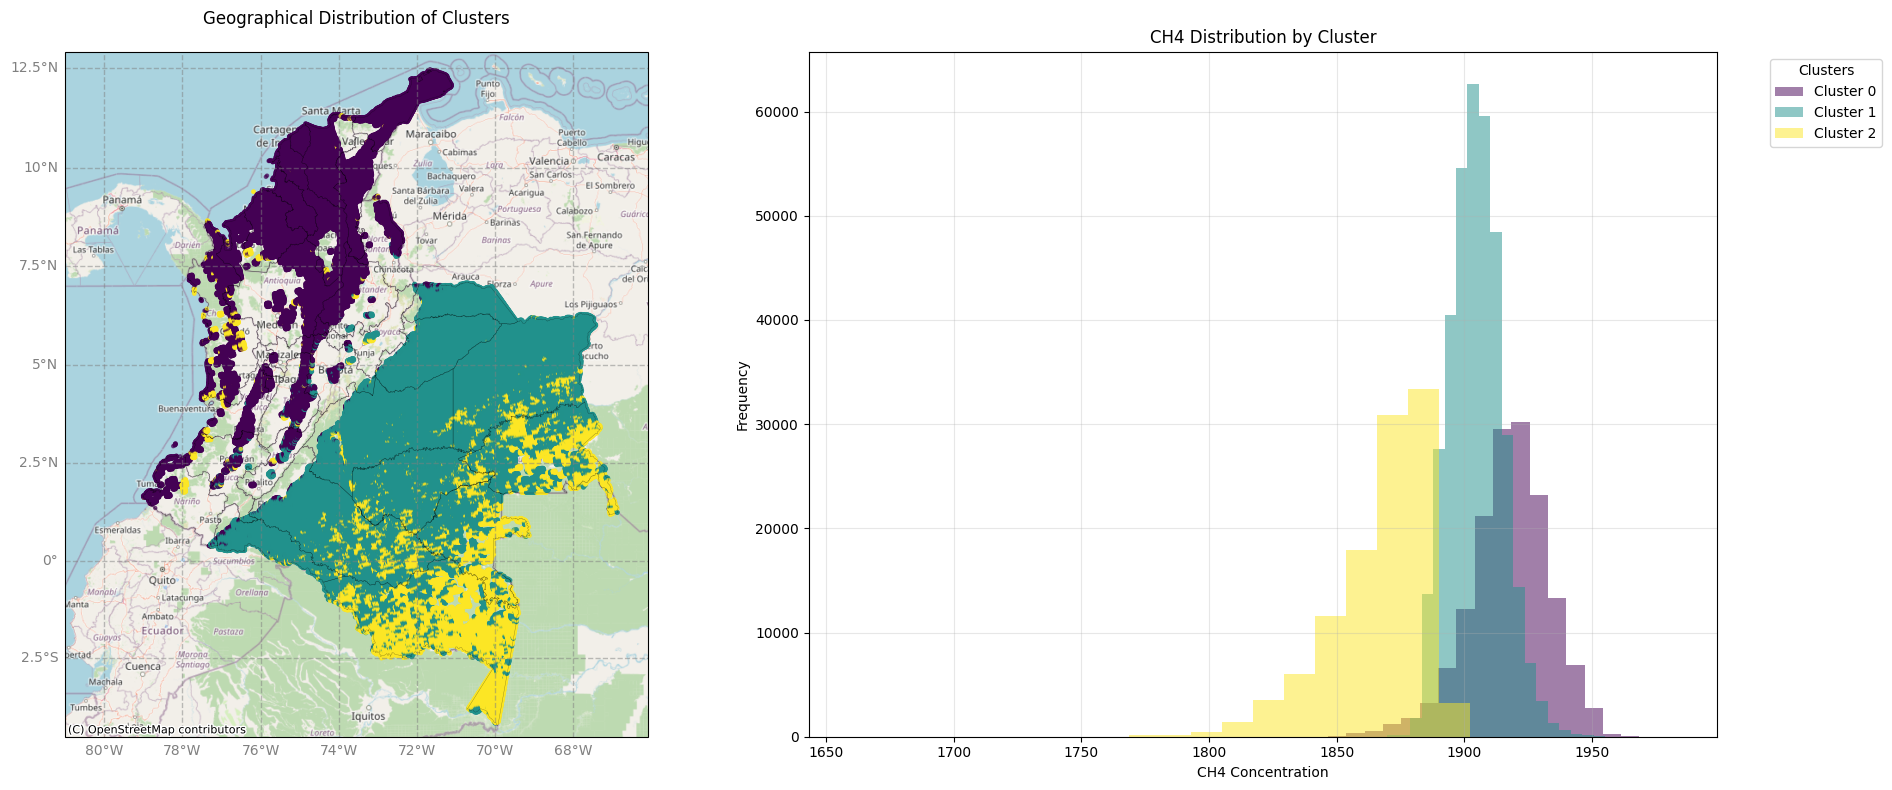


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0                                                  1917.50     15.59  153612   
1                                                  1904.60     10.18  365224   
2                                                  1866.77     18.91  108602   

        longitude latitude  
             mean     mean  
cluster                     
0          -74.78     8.03  
1          -71.74     2.88  
2          -71.06     0.18  


In [8]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r,
    geometry=gpd.points_from_xy(r.longitude, r.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Define cluster colors
clusters = gdf_points['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)))

# Plot clusters on map
# for cluster, color in zip(clusters, colors):
#     cluster_data = gdf_points[gdf_points['cluster'] == cluster]
#     ax1.scatter(
#         cluster_data.longitude,
#         cluster_data.latitude,
#         color=color,
#         label=f'Cluster {cluster}',  # Add cluster number as label
#         transform=ccrs.PlateCarree(),
#         s=5,  # Marker size
#         alpha=0.6
#     )
    
# Plot clusters on map
scatter = ax1.scatter(
                        gdf_points.longitude,
                        gdf_points.latitude,
                        c=gdf_points.cluster,
                        cmap='viridis',
                        alpha=0.6,
                        transform=ccrs.PlateCarree(),
                        s=5  # Marker size, smaller values mean smaller circles
                    )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map
# legend = ax1.legend(title='Clusters', loc='upper right', bbox_to_anchor=(1.15, 1))
# plt.setp(legend.get_title(), fontsize=10)  # Adjust legend title font size

if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
colors = plt.cm.viridis(np.linspace(0, 1, optimal_k))  # Use same colormap as map

ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(optimal_k):
    cluster_data = r[r['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.5, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters.png', dpi=1200, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

In [9]:
import ee
from shapely.geometry import shape, Point
ee.Initialize()


*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_0JLhFqfSY1uiEaW?source=Init


In [10]:
pacifico_asset = ee.FeatureCollection('projects/ee-hides/assets/pacifico')
magdalena_asset = ee.FeatureCollection('projects/ee-hides/assets/magdalena')


In [11]:
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_1 = pacifico_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_1]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 3  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon
r['cluster'] = r.apply(update_cluster, axis=1)
# Convert MultiPolygon from FeatureCollection to Shapely polygons
features_2 = magdalena_asset.getInfo()['features']
shapely_polygons = [shape(feat['geometry']) for feat in features_2]

# Update 'cluster' column with a fixed value if the point is inside any polygon
def update_cluster(row):
    point = Point(row['longitude'], row['latitude'])
    for polygon in shapely_polygons:
        if polygon.contains(point):
            return 4  # Set the fixed cluster value to 3
    return row['cluster']  # Keep the original cluster if not inside any polygon

r['cluster'] = r.apply(update_cluster, axis=1)


GeoDataFrame already has CRS: EPSG:3857


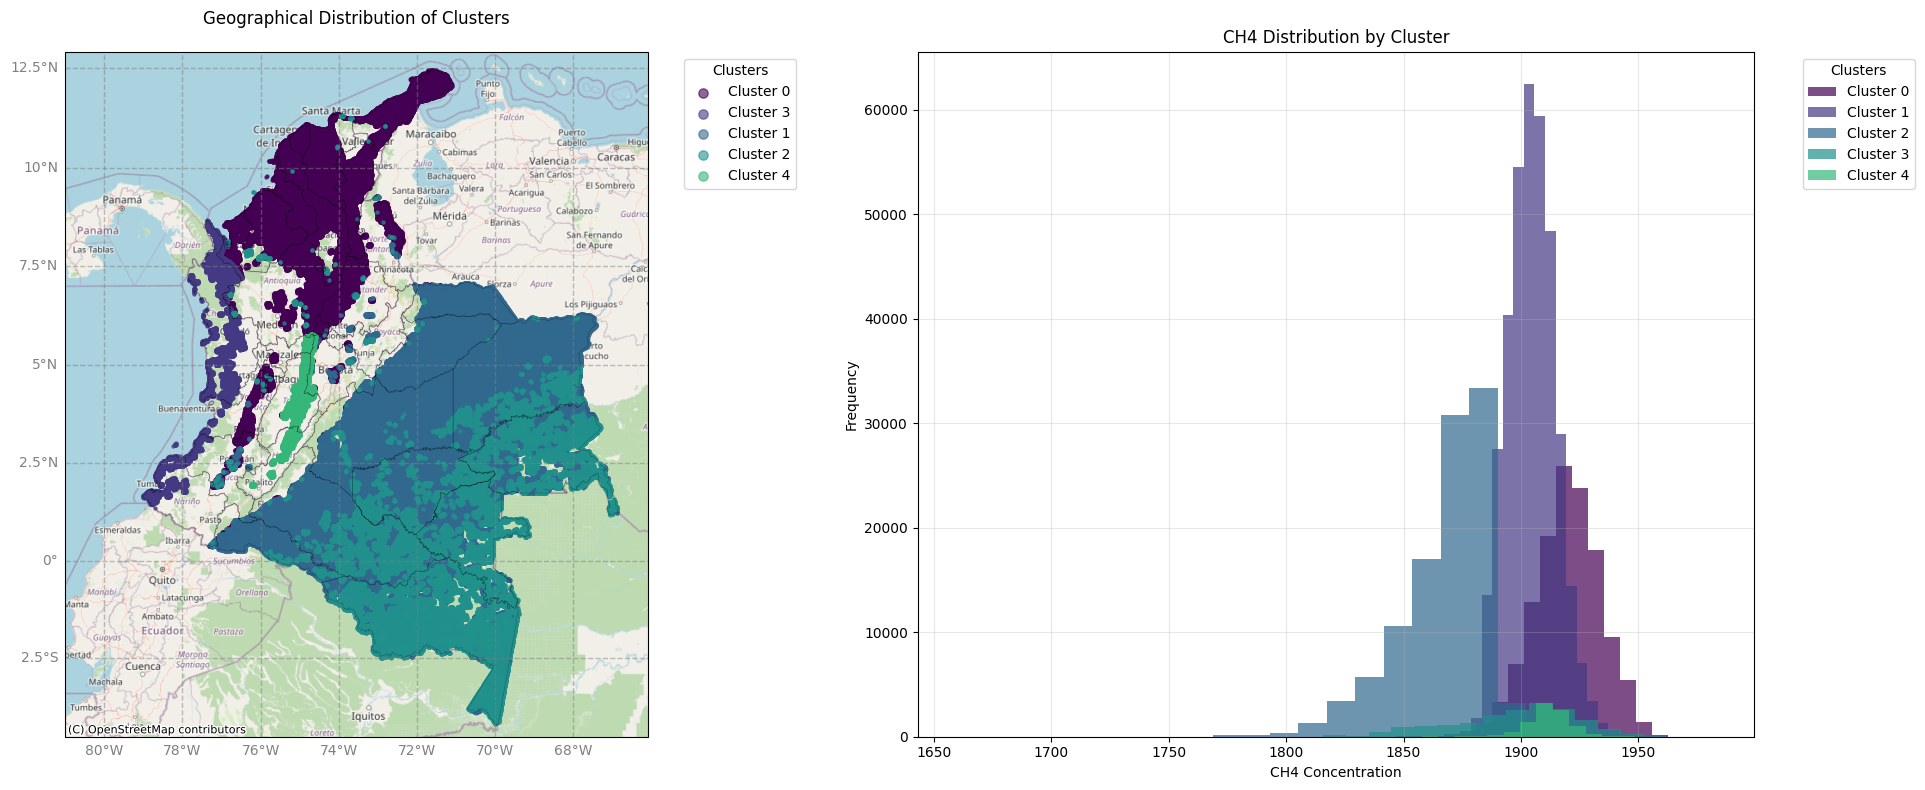


Cluster Statistics:
        CH4_column_volume_mixing_ratio_dry_air_bias_corrected                 \
                                                         mean    std   count   
cluster                                                                        
0.0                                                1919.52     14.25  129056   
1.0                                                1904.62     10.18  364306   
2.0                                                1867.18     18.83  106114   
3.0                                                1896.48     26.94   18404   
4.0                                                1911.18     11.05    9558   

        longitude latitude  
             mean     mean  
cluster                     
0.0        -74.46     8.61  
1.0        -71.74     2.88  
2.0        -70.92     0.07  
3.0        -77.21     5.39  
4.0        -75.03     4.10  


In [12]:
# Create figure and axes
fig = plt.figure(figsize=(20, 8))
gs = GridSpec(1, 2, figure=fig)

# First subplot - Map with clusters
ax1 = fig.add_subplot(gs[0], projection=ccrs.epsg(3857))

# Set map extent
extent = [-81, -66.1, -4.5, 12.9]
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Create GeoDataFrame from your clusters data
gdf_points = gpd.GeoDataFrame(
    r,
    geometry=gpd.points_from_xy(r.longitude, r.latitude),
    crs="EPSG:4326"
)

# Convert to web mercator for contextily basemap
gdf_points_mercator = gdf_points.to_crs(epsg=3857)

# Convertir la columna 'cluster' a enteros
gdf_points['cluster'] = gdf_points['cluster'].astype(int)

# Verificar los valores únicos después de la conversión
clusters = gdf_points['cluster'].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(clusters)+2))

# Plot clusters on map with legend
for cluster, color in zip(clusters, colors):
    cluster_data = gdf_points[gdf_points['cluster'] == cluster]
    ax1.scatter(
        cluster_data.longitude,
        cluster_data.latitude,
        color=color,
        label=f'Cluster {cluster}',  # Add cluster number as label
        transform=ccrs.PlateCarree(),
        s=5,  # Marker size
        alpha=0.6
    )
    
# Plot clusters on map without legend
# scatter = ax1.scatter(
#                         gdf_points.longitude,
#                         gdf_points.latitude,
#                         c=gdf_points.cluster,
#                         cmap='viridis',
#                         alpha=0.6,
#                         transform=ccrs.PlateCarree(),
#                         s=5  # Marker size, smaller values mean smaller circles
#                     )

# Add basemap 
cx.add_basemap(ax1, 
               source=cx.providers.OpenStreetMap.Mapnik)

# Add gridlines
gl = ax1.gridlines(crs=ccrs.PlateCarree(), 
                   draw_labels=True,
                   linewidth=1, 
                   color='gray', 
                   alpha=0.5, 
                   linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Add colorbar to map
# cbar = plt.colorbar(scatter, ax=ax1)
# cbar.set_label('Cluster', fontsize=10)

# Add legend to map with larger points
legend = ax1.legend(
    title='Clusters', 
    loc='upper left', 
    bbox_to_anchor=(1.05, 1),
    markerscale=3  # Increase the size of points in the legend
)

# Adjust legend title font size
plt.setp(legend.get_title(), fontsize=10)



if gdf.crs is None:
    # Only set CRS if it doesn't have one
    gdf.set_crs(epsg=4326, inplace=True)
else:
    print("GeoDataFrame already has CRS:", gdf.crs)
gdf = gdf.to_crs(epsg=3857)
              
gdf.plot(ax=ax1, edgecolor='black', facecolor='none', linewidth=0.3, alpha=0.4)


# Add title to map
ax1.set_title('Geographical Distribution of Clusters', pad=20)





# Second subplot - Methane distribution
ax2 = fig.add_subplot(gs[1])
#colors = plt.cm.viridis(np.linspace(0, 1, optimal_k+2))  # Use same colormap as map

ax2.set_xlabel('CH4 Concentration')
ax2.set_ylabel('Frequency')
ax2.set_title('CH4 Distribution by Cluster')


for i in range(optimal_k+2):
    cluster_data = r[r['cluster'] == i]
    ax2.hist(cluster_data['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'], 
             alpha=0.7, 
             label=f'Cluster {i}',
             color=colors[i],  # Match colors with map
             bins=20)  # Adjust number of bins

# Add grid to histogram
ax2.grid(True, alpha=0.3)

# Customize histogram legend
ax2.legend(title='Clusters', 
          bbox_to_anchor=(1.05, 1), 
          loc='upper left')

# Adjust layout and save
plt.tight_layout()
plt.savefig('clusters.png', dpi=600, bbox_inches='tight')
plt.show()

# Print cluster statistics
print("\nCluster Statistics:")
print(r.groupby('cluster').agg({
    'CH4_column_volume_mixing_ratio_dry_air_bias_corrected': ['mean', 'std', 'count'],
    'longitude': 'mean',
    'latitude': 'mean'
}).round(2))

# Clasificación

Debido a que anteriormente, ningún clasificador hizo un buen trabajo, y simplemente tomaba toda la región del país como perteneciente a una misma intancia, se busca crear una red neuronal que haga la tarea de clasificación.

In [13]:
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F

In [14]:
#X = r[['longitude', 'latitude', 'CH4_column_volume_mixing_ratio_dry_air_bias_corrected']].to_numpy()
y= r['cluster'].to_numpy()
X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)

In [15]:
np.unique(Y_train)

array([0., 1., 2., 3., 4.])

In [19]:
class Data(Dataset):
  def __init__(self, X_train, y_train):
    # need to convert float64 to float32 else
    # will get the following error
    # RuntimeError: expected scalar type Double but found Float
    self.X = torch.from_numpy(X_train.astype(np.float32))
    # need to convert float64 to Long else
    # will get the following error
    # RuntimeError: expected scalar type Long but found Float
    self.y = torch.from_numpy(y_train).type(torch.LongTensor)
    self.len = self.X.shape[0]

  def __getitem__(self, index):
    return self.X[index], self.y[index]
  def __len__(self):
    return self.len

In [17]:
traindata = Data(X_train, Y_train)
print(traindata[25])

(tensor([-74.1850,  -0.5050]), tensor(1))


In [20]:

# number of features (len of X cols)
input_dim = 2
# number of hidden layers
hidden_layers = 25
#hidden_layers2 = 125
# number of classes (unique of y)
output_dim = len(np.unique(Y_train))
class Network(nn.Module):
    def __init__(self,hidden_layers):
        super(Network, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_layers)
        #self.linearh1=nn.Linear(hidden_layers,hidden_layers2)
        self.linear2 = nn.Linear(hidden_layers, output_dim)
    def forward(self, x):
        x = F.leaky_relu(self.linear1(x))
        #x = torch.sigmoid(self.linearh1(x))
        x = self.linear2(x)
        #x = F.softmax(x)
        return x


In [21]:
epochs = 40
def run_epoch(epoch,ta,clf):
    criterion = nn.MultiMarginLoss()#nn.MultiMarginLoss()#nn.HingeEmbeddingLoss#nn.MultiLabelMarginLoss()##
    optimizer = torch.optim.Adam(clf.parameters(), lr=ta)
    for epoch in range(epochs):
      running_loss = 0.0
      for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        # set optimizer to zero grad to remove previous epoch gradients
        optimizer.zero_grad()
        # forward propagation
        outputs = clf(inputs)
        loss = criterion(outputs, labels)
        # backward propagation
        loss.backward()
        # optimize
        optimizer.step()
        running_loss += loss.item()
      # display statistics
    print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.5f}')

In [22]:
def test_val(clf):
    correct, total = 0, 0
    # no need to calculate gradients during inference
    with torch.no_grad():
      for data in testloader:
        inputs, labels = data
        # calculate output by running through the network
        outputs = clf(inputs)
        # get the predictions
        __, predicted = torch.max(outputs.data, 1)
        # update results
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    print(f'Accuracy of the network on the {len(testdata)} test data: {100 * correct // total} %')
    return correct/total

In [23]:
def parameters_train(ep,ta,hl):
    #nn_arch(hidden_layers)
    clf = Network(hl)
    epochs = ep
    lr=ta
    run_epoch(epoch,lr,clf)
    score=test_val(clf)
    return score

In [22]:
#Se busca el mejor parámetro para la cantidad de capas ocultas
hd=np.arange(2,30,1)
epoch=40
lr=0.005
val_scores_hl=[]
batch_size = 500
cv=5
for hidden_layers in hd:
    print(hidden_layers)
    val_scores_hl_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=10)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=10)
        val_scores_hl_cv.append(parameters_train(epoch,lr,hidden_layers))
    val_scores_hl.append(np.mean(val_scores_hl_cv))

2
[40,   841] loss: 0.03391
Accuracy of the network on the 207055 test data: 83 %
[40,   841] loss: 0.03362
Accuracy of the network on the 207055 test data: 86 %
[40,   841] loss: 0.03554
Accuracy of the network on the 207055 test data: 83 %
[40,   841] loss: 0.03271
Accuracy of the network on the 207055 test data: 85 %
[40,   841] loss: 0.03580
Accuracy of the network on the 207055 test data: 84 %
3
[40,   841] loss: 0.03330
Accuracy of the network on the 207055 test data: 84 %
[40,   841] loss: 0.03354
Accuracy of the network on the 207055 test data: 86 %
[40,   841] loss: 0.03162
Accuracy of the network on the 207055 test data: 86 %
[40,   841] loss: 0.04039
Accuracy of the network on the 207055 test data: 82 %
[40,   841] loss: 0.03392
Accuracy of the network on the 207055 test data: 85 %
4
[40,   841] loss: 0.02941
Accuracy of the network on the 207055 test data: 84 %
[40,   841] loss: 0.03025
Accuracy of the network on the 207055 test data: 85 %
[40,   841] loss: 0.03278
Accuracy

HL_star = 13


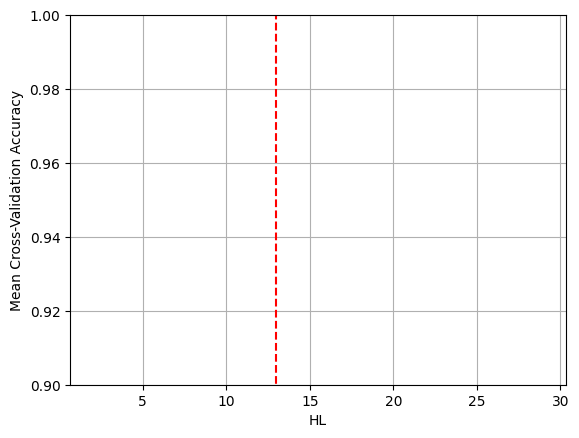

In [23]:
#Se encuentra la mejor cantidad de puntos en la capa oculta
ind = np.argmax(val_scores_hl)
hl_star = 13 #hd[ind] #Resultó ser 13
print('HL_star =', hl_star)

plt.plot(hd,val_scores_hl)
plt.plot(np.ones(11)*hl_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.9,1)
plt.ylim(0.9,1)
plt.xlabel('HL')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [24]:
# Se busca el mejor valor para la tasa de aprendizaje
epoch=40
lr=np.arange(1e-5,0.01,5e-4)
val_scores_lr=[]
batch_size = 500
cv=4
for i in lr:
    #print(clf.parameters)
    print(i)
    val_scores_lr_cv=[]
    for j in range(cv):
        X_train, X_test, Y_train, Y_test = train_test_split(X[:,[0,1]], y, test_size=0.33)
        traindata = Data(X_train, Y_train)
        trainloader = DataLoader(traindata, batch_size=batch_size,
                         shuffle=True, num_workers=10)
        testdata = Data(X_test, Y_test)
        testloader = DataLoader(testdata, batch_size=batch_size,
                                shuffle=True, num_workers=10)
        val_scores_lr_cv.append(parameters_train(epoch,i,hl_star))
    val_scores_lr.append(np.mean(val_scores_lr_cv))

1e-05
[40,   841] loss: 0.07211
Accuracy of the network on the 207055 test data: 73 %
[40,   841] loss: 0.07276
Accuracy of the network on the 207055 test data: 74 %
[40,   841] loss: 0.07555
Accuracy of the network on the 207055 test data: 74 %
[40,   841] loss: 0.08008
Accuracy of the network on the 207055 test data: 72 %
0.00051
[40,   841] loss: 0.05791
Accuracy of the network on the 207055 test data: 77 %
[40,   841] loss: 0.04675
Accuracy of the network on the 207055 test data: 82 %
[40,   841] loss: 0.05443
Accuracy of the network on the 207055 test data: 80 %
[40,   841] loss: 0.04892
Accuracy of the network on the 207055 test data: 82 %
0.00101
[40,   841] loss: 0.03300
Accuracy of the network on the 207055 test data: 84 %
[40,   841] loss: 0.03790
Accuracy of the network on the 207055 test data: 84 %
[40,   841] loss: 0.03906
Accuracy of the network on the 207055 test data: 84 %
[40,   841] loss: 0.04122
Accuracy of the network on the 207055 test data: 82 %
0.00151
[40,   841

LR_star = 0.007509999999999999


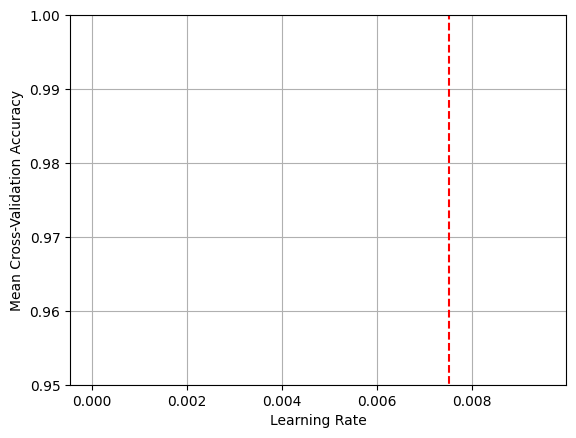

In [26]:
ind = np.argmax(val_scores_lr)
lr_star = lr[ind] # resulto ser LR_star = 0.007509999999999999
print('LR_star =', lr_star)

plt.plot(lr,val_scores_lr)
plt.plot(np.ones(11)*lr_star,np.arange(0,1.1,0.1),'--r')
#plt.xlim(0.95,1)
plt.ylim(0.95,1)
plt.xlabel('Learning Rate')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.grid(True)
plt.show()

In [17]:
# save the trained model
#clf = Network(hl_star)
PATH = 'mymodel_prueba.pth'
#torch.save(clf.state_dict(), PATH)

NameError: name 'Network' is not defined

In [25]:
# load the trained model
hl_star = 13
clf = Network(hl_star)
clf.load_state_dict(torch.load(PATH))

/tmp/ipykernel_16972/2636491605.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  clf.load_state_dict(torch.load(PATH))


<All keys matched successfully>

In [35]:
# mapa con la clasificación de resultado
#sns.scatterplot(x=inputs[:,0],y=inputs[:,1])#],hue='label',s=1,palette=sns.color_palette("tab10"))
y_pred=[]

batch_size = 500

testdata = Data(X[:,[0,1]], y)

testloader = DataLoader(testdata, batch_size=batch_size, shuffle=True, num_workers=10)
for data in testloader:
    inputs, labels = data
    # calculate output by running through the network
    outputs = clf(inputs)
    # get the predictions
    __, predicted = torch.max(outputs.data, 1)
    y_pred.append(predicted)
# fig, ax = plt.subplots()
# for label in [0, 1,2,3]:
#     mask = (y_pred == label)
#     ax.scatter(inputs[mask, 0], inputs[mask, 1],s=0.3)
#plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

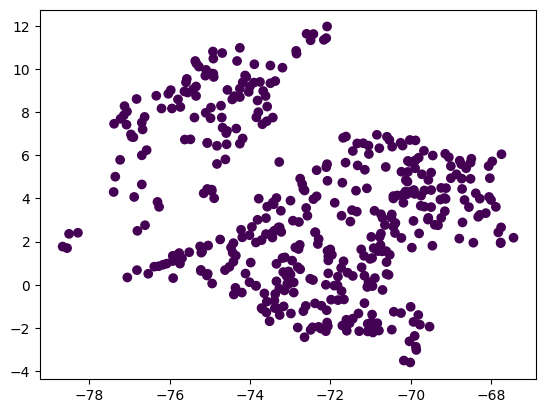

In [36]:
plt.scatter(inputs[:,0],inputs[:,1],c=predicted)

In [37]:
predicted

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,